In [1]:
from baseline_tools import *
from filters import *
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from tools import load_models

In [2]:
# Works only for short.

In [3]:
all_locs = ["Fuerwigge", 'Moehne', 'Verse', 'Lister','Bigge', 'Sorpe',] # "Henne"
all_dirs = ['ver', "ew", "asc0", "desc0", "asc1", "desc1"]
all_locs = [ 'Moehne'] # "Henne"
all_dirs = [ "desc1"]
#grid_path = "grid_results"
#fore = "forecasts"
#out_path = "results"
path = "grid_results_short"
p2 = Path(path)


# Data check 

In [4]:
data, df = build_sarimax_ds(
    location="Moehne" ,
    direction= "desc1",
    fourier_order=0,
    external_timesteps = [],
    mean_period=0) 

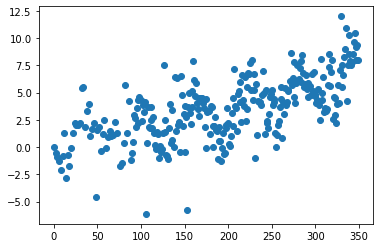

In [5]:
plt.scatter(np.arange(len(data["10905"])),data["10905"])

# Residuals 

In [6]:
%%capture
out = load_models("Moehne", "desc1")

In [8]:
out['10905'][0].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  289
Model:               SARIMAX(4, 1, 1)   Log Likelihood                 134.970
Date:                Wed, 27 Sep 2023   AIC                           -243.941
Time:                        17:28:24   BIC                           -196.322
Sample:                             0   HQIC                          -224.858
                                - 289                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0015      0.001      2.803      0.005       0.000       0.003
x1            -0.2240      0.047     -4.770      0.000      -0.316      -0.132
x2             0.0304      0.071      0.428      0.668      -0.109       0.170
x3             0.4099      0.992      0.413      0.679      -1.534       2.354
x4            -0.1098      0.119     -0.924      0.355      -0.343       0.123
x5            -0.4402      1.000     -0.440      0.660      -2.400       1.520
x6            -0.2659      0.123     -2.155      0.031      -0.508      -0.024
ar.L1          0.0393      0.075      0.524      0.601      -0.108       0.187
ar.L2          0.0849      0.077      1.100      0.271      -0.066       0.236
ar.L3         -0.0549      0.078     -0.699      0.484      -0.209       0.099
ar.L4         -0.1166      0.076     -1.537      0.124      -0.265       0.032
ma.L1         -0.9488      0.040    -23.681      0.000      -1.027      -0.870
sigma2         0.0174      0.002     10.426      0.000       0.014       0.021
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                22.83
Prob(Q):                              0.83   Prob(JB):                         0.00
Heteroskedasticity (H):               1.78   Skew:                             0.20
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Text(0.5, 0.98, 'Residual distribution (Normalized)')

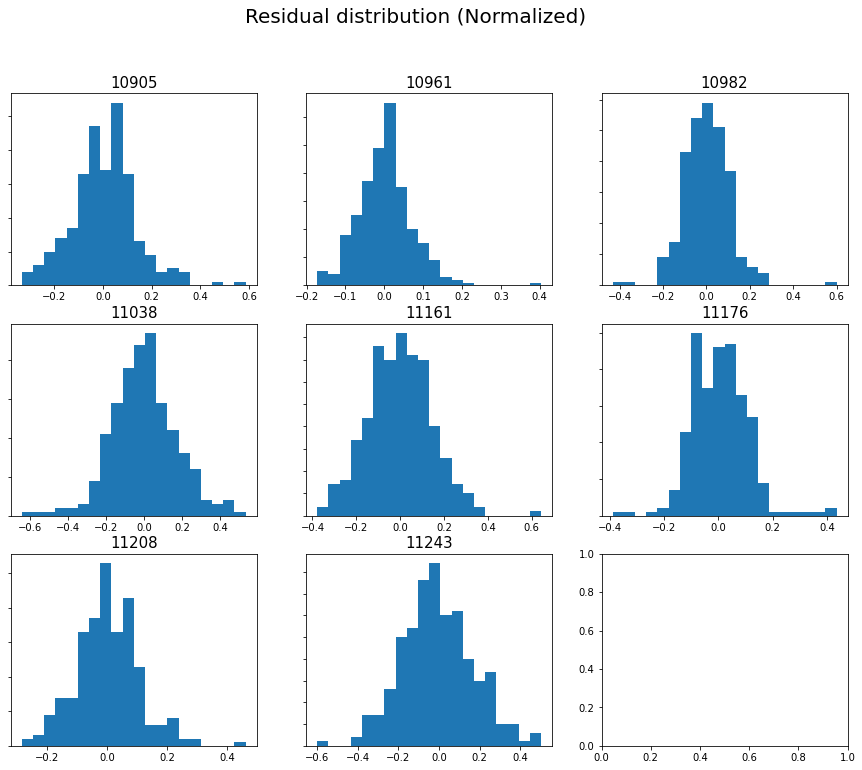

In [62]:
fig, axs = plt.subplots(3,3,figsize=(15,12))
for n,y in enumerate(out):
    axs.reshape(-1)[n].hist(pd.DataFrame(out[y].resid).interpolate().values, bins=20)
    axs.reshape(-1)[n].yaxis.set_ticklabels([])
    axs.reshape(-1)[n].set_title(y, fontsize=15)
fig.suptitle("Residual distribution (Normalized)", fontsize=20)

# MAE

In [78]:
def mse_loc_dir(loc, direction, path=Path("results_short")):
        data, _ = build_sarimax_ds(
        location=loc ,
        direction= direction,
        fourier_order=0,
        external_timesteps = [],
        mean_period=0) 
        data = data.loc[data.index.year == 2020]

        pred = pd.read_csv(path  / (loc + "_" + direction + ".csv"), index_col=0)
        return data, pred

In [79]:
res = mse_loc_dir("Moehne", "desc1")

In [80]:
pd.DataFrame((res[0] - res[1].values).abs().mean(), columns = ["Mean Absolute Error in mm"])

,Mean Absolute Error in mm
10905,1.390292
10961,0.748073
10982,1.005817
11038,3.820771
11161,2.087332
11176,1.995165
11208,1.416444
11243,3.642073


# Params used

In [158]:
# Residuals: 
def load_models(location, direction, path = "results_short"):

    #load grid search results
    p = path +  "/" +  (location + "_" + direction + "_models.csv")
    out = pd.read_csv(p, index_col=0)
    return out
   

In [169]:
d = load_models("Moehne", "desc1")
d[d.isnull()] = 0

In [180]:
pd.DataFrame(d.mean(), column = "Average parameter strength") pd.DataFrame((d != 0).sum(), columns = "Parameter non zero")

,0,1
0,T0 -0.104938 T1 0.0...,T0 8 T1 3 T2 ...


In [197]:
a = pd.DataFrame(d.mean(), columns = ["Average absolute parameter strength"])
b = pd.DataFrame((d != 0).sum(), columns = ["Models that include this parameter"])

pd.concat([a,b], axis=1).sort_values("Average absolute parameter strength")

,Average absolute parameter strength,Models that include this parameter
W0,-0.659437,8
ma.L1,-0.658737,7
W1,-0.483650,3
"sin(1,365.24)",-0.140500,7
T0,-0.104938,8
ma.L2,-0.104375,2
ar.L4,-0.032625,3
ar.L3,-0.006200,4
TM6,-0.001412,3
"cos(1,365.24)",0.004188,7


# Wetter as explainer for trend?

In [203]:
data, exog = build_sarimax_ds(
        location="Moehne" ,
        direction= "desc1",
        fourier_order=0,
        external_timesteps = [0,1,2],
        mean_period=6) 

/home/stein/project_repos/dam/full_baseline/baseline_tools.py:200: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean.rename(columns= {


<AxesSubplot:>

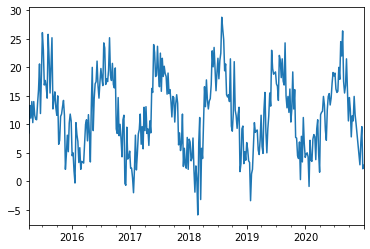

In [204]:
exog["T0"].plot()

In [ ]:
# Nope.